1. Download the two image files, bird.png and cat.png, and place them in the files folder. Apply the center_crop() function on them, and then resize them to a size of  3×512×512 . Name them image3 and image4, respectively. Print out the shape of the two processed images.

In [1]:
import requests, os

# urls for the files
urls=("https://huggingface.co/ogkalu/Illustration-Diffusion"
    "/resolve/main/hollie-mengert.ckpt?download=true",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/merges.txt",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/vocab.json")

files=["files/hollie-mengert.ckpt",
       "files/merges.txt",
       "files/vocab.json"] #Where to save the three files

# Ensure the 'files' directory exists
os.makedirs('files', exist_ok=True)

if all(os.path.exists(file) for file in files): #Checks if the three files already exist
    print("files have already been downloaded")
else: #If not, downloads the three files
    print("downloading files")
    for url, file in zip(urls, files):
        fb=requests.get(url)
        with open(file,"wb") as f:
            f.write(fb.content)
    print("download complete")

files have already been downloaded


In [2]:
!git clone https://github.com/hkproj/pytorch-stable-diffusion

fatal: destination path 'pytorch-stable-diffusion' already exists and is not an empty directory.


In [3]:
# access the directory /pytorch-stable-diffusion/sd/
import sys
sys.path.append("pytorch-stable-diffusion/sd")    #Accesses the subdirectory in the cloned GitHub repository

from model_converter import load_from_standard_weights
from encoder import VAE_Encoder
from decoder import VAE_Decoder
import torch

model_file = "files/hollie-mengert.ckpt"
state_dict = load_from_standard_weights(model_file,
        "cpu")    #Loads the pretrained weights in the VAE
encoder = VAE_Encoder()
encoder.load_state_dict(state_dict['encoder'],
        strict=True)    #Creates the VAE encoder
decoder = VAE_Decoder()
decoder.load_state_dict(state_dict['decoder'],
        strict=True)    #Creates the VAE decoder

<All keys matched successfully>

In [4]:
from PIL import Image
from torchvision import transforms

def center_crop(img):    #Defines a function to center crop an image
    width, height = img.size
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im
image3=center_crop(Image.open(
    "files/bird.png")).resize((512,512))    #Loads the beaver image and resizes it to 3 × 512 × 512
image4=center_crop(Image.open(
    "files/cat.png")).resize((512,512))    #Loads the dolphin image and resizes it to 3 × 512 × 512
transform=transforms.ToTensor()
image3=transform(image3)
image4=transform(image4)
print(image3.shape, image4.shape)    #Prints out the shapes of the resized images

torch.Size([3, 512, 512]) torch.Size([3, 512, 512])


2. Use the VAE encoder to compress the two images, image3 and image4, to the latent space so that they have a shape of  4×64×64 . Name the two latent images latent3 and latent4.

In [5]:
N=torch.distributions.Normal(0, 1)
noise=N.sample(torch.Size([1,4,64,64]))    #aici----------------------------------
latent3=encoder(image3.unsqueeze(0),
    noise)[0]
latent4=encoder(image4.unsqueeze(0),
    noise)[0]    #Compresses the beaver and dolphin images to the latent space
print(latent3.shape,latent4.shape)    #Prints out the shape of the compressed images

torch.Size([4, 64, 64]) torch.Size([4, 64, 64])


3. Plot the two original images, image3 and image4, and the two latent images, latent3 and latent4, in a  1×4  grid to compare them.

In [6]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

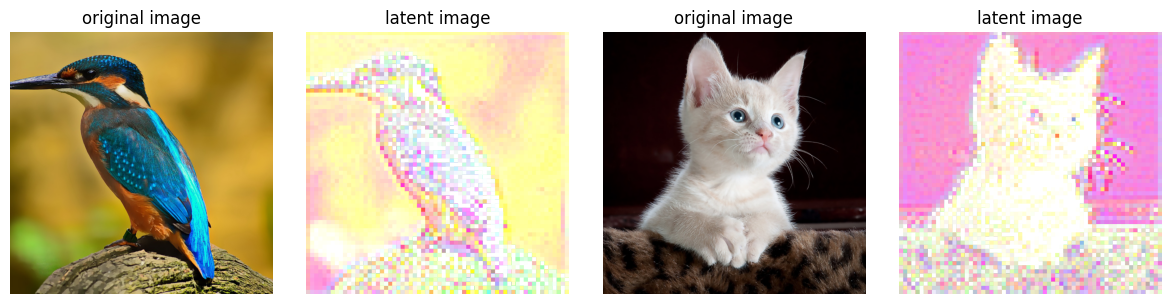

In [7]:
import matplotlib.pyplot as plt
import numpy as np

imgs=[image3.permute(1,2,0),
  torch.clip(latent3.permute(1,2,0),-1,1).detach().cpu().numpy(
      ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
      image4.permute(1,2,0),\
  torch.clip(latent4.permute(1,2,0),-1,1).detach().cpu().numpy(
  ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5]    #Places the original images and compressed images in one list
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("latent image")    #Labels each image as either original or latent
    plt.axis('off')
plt.tight_layout()
plt.show()

4. Use the pretrained VAE decoder to convert the two latent images, latent3 and latent4, into two high-dimensional images. Name them reconstruct3 and reconstruct4, respectively. Then, plot the two original images, image3 and image4, and the two reconstructed images in a  1×4  grid to compare them.


# Am modificat la 128 si 16 pentru a mai crapa RAM ul

In [8]:
import requests, os

# urls for the files
urls=("https://huggingface.co/ogkalu/Illustration-Diffusion"
    "/resolve/main/hollie-mengert.ckpt?download=true",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/merges.txt",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/vocab.json")

files=["files/hollie-mengert.ckpt",
       "files/merges.txt",
       "files/vocab.json"] #Where to save the three files

# Ensure the 'files' directory exists
os.makedirs('files', exist_ok=True)

if all(os.path.exists(file) for file in files): #Checks if the three files already exist
    print("files have already been downloaded")
else: #If not, downloads the three files
    print("downloading files")
    for url, file in zip(urls, files):
        fb=requests.get(url)
        with open(file,"wb") as f:
            f.write(fb.content)
    print("download complete")

files have already been downloaded


In [9]:
!git clone https://github.com/hkproj/pytorch-stable-diffusion

fatal: destination path 'pytorch-stable-diffusion' already exists and is not an empty directory.


In [10]:
from PIL import Image
from torchvision import transforms

def center_crop(img):    #Defines a function to center crop an image
    width, height = img.size
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im
image3=center_crop(Image.open(
    "files/bird.png")).resize((128,128))    #Loads the beaver image and resizes it to 3 × 512 × 512
image4=center_crop(Image.open(
    "files/cat.png")).resize((128,128))    #Loads the dolphin image and resizes it to 3 × 512 × 512
transform=transforms.ToTensor()
image3=transform(image3)
image4=transform(image4)
print(image3.shape, image4.shape)    #Prints out the shapes of the resized images

torch.Size([3, 128, 128]) torch.Size([3, 128, 128])


In [11]:
N=torch.distributions.Normal(0, 1)
noise=N.sample(torch.Size([1,4,16,16]))    #aici----------------------------------
latent3=encoder(image3.unsqueeze(0),
    noise)[0]
latent4=encoder(image4.unsqueeze(0),
    noise)[0]    #Compresses the beaver and dolphin images to the latent space
print(latent3.shape,latent4.shape)    #Prints out the shape of the compressed images

torch.Size([4, 16, 16]) torch.Size([4, 16, 16])


In [12]:
reconstruct3=decoder(latent3.unsqueeze(0))
reconstruct4=decoder(latent4.unsqueeze(0))
print(reconstruct3.shape,reconstruct4.shape)

torch.Size([1, 3, 128, 128]) torch.Size([1, 3, 128, 128])


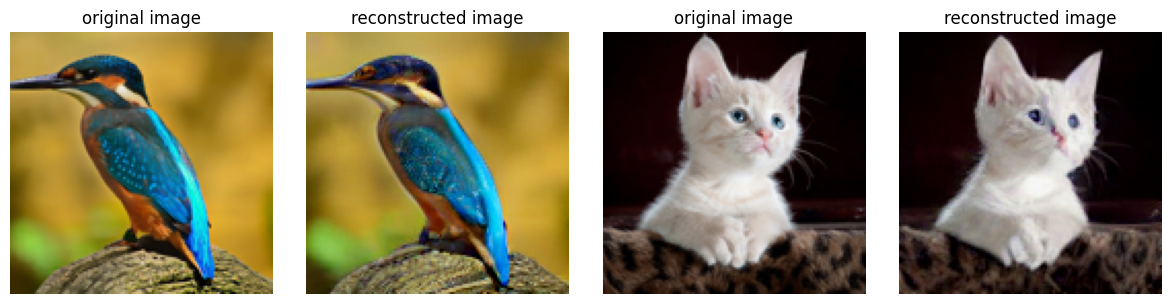

In [13]:
imgs=[image3.permute(1,2,0),
  torch.clip(reconstruct3[0].permute(1,2,0),
    0,1).detach().cpu().numpy(),
    image4.permute(1,2,0),
  torch.clip(reconstruct4[0].permute(1,2,0),
             0,1).detach().cpu().numpy()]    #Places original and reconstructed images in a list
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #Plots the four images in a 1 × 4 grid
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("reconstructed image")    #Labels each image as either original or reconstructed
    plt.axis('off')
plt.tight_layout()
plt.show()

5. Use “A dog walks on the white, snow-covered ground” as the prompt to modify the existing horse image. Set the strength parameter to 0.5, the cfg_scale parameter to 8, and the random state number (i.e., the seed argument in the generate() function) to 42. Plot the generated image.

In [14]:
!pip install transformers==4.55.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 103.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [15]:
from transformers import CLIPTokenizer
from clip import CLIP

device="cuda" if torch.cuda.is_available() else "cpu"
decoder.to(device)
tokenizer = CLIPTokenizer(vocab_file="files/vocab.json",
    merges_file="files/merges.txt", use_fast=False)    #Instantiates the CLIPTokenizer() class
clip = CLIP().to(device)    #Creates a CLIP model
clip.load_state_dict(state_dict['clip'],
    strict=True)    #Loads pretrained weights to the CLIP model

<All keys matched successfully>

In [16]:
prompt = '''A dog walks on the white, snow-covered ground'''

uncond_prompt=""

seed=42
with torch.no_grad():
    generator=torch.Generator(device=device)
    generator.manual_seed(seed)
    cond_tokens=tokenizer.batch_encode_plus(
    [prompt], padding="max_length", max_length=77).input_ids
    print(cond_tokens)
    cond_tokens=torch.tensor(cond_tokens,
        dtype=torch.long,device=device)    #Tokenizes the conditional prompt into a 77-token tensor
    print("conditional tokens are\n", cond_tokens)
    cond_context = clip(cond_tokens).to(device)    #Uses the CLIP text encoder to encode the conditional prompt
    uncond_tokens=tokenizer.batch_encode_plus(
        [uncond_prompt], padding="max_length",
        max_length=77).input_ids
    uncond_tokens=torch.tensor(uncond_tokens,
       dtype=torch.long,device=device)
    print("unconditional tokens are\n", uncond_tokens)
    uncond_context = clip(uncond_tokens).to(device)    #Does the same for the unconditional prompt
    clip.to("cpu")
    context=torch.cat([cond_context,uncond_context])    #Concatenates encoded conditional and unconditional prompts

[[49406, 320, 1929, 8192, 525, 518, 1579, 267, 2583, 268, 5603, 2461, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407]]
conditional tokens are
 tensor([[49406,   320,  1929,  8192,   525,   518,  1579,   267,  2583,   268,
          5603,  2461, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 4940

In [17]:
from diffusion import Diffusion
import torch
from ddpm import DDPMSampler

diffusion = Diffusion().to(device)
diffusion.load_state_dict(state_dict['diffusion'],
    strict=True)    #Initiates the diffusion model from the GitHub repository and loads pretrained weights
def get_time_embedding(timestep):    #Creates time embedding
    freqs = torch.pow(10000, -torch.arange(start=0,
                   end=160, dtype=torch.float32) / 160)
    x = torch.tensor([timestep],
         dtype=torch.float32)[:, None] * freqs[None]
    return torch.cat([torch.cos(x), torch.sin(x)], dim=-1)
num_reference_steps=50
sampler=DDPMSampler(generator)
sampler.set_inference_timesteps(num_reference_steps)    #Creates a noise scheduler and sets the number of inference time steps to 50

In [18]:
from tqdm import tqdm
from copy import deepcopy

cfg_scale=8
latent_shape=(1,4,16,16)
noisy_latents=[]
with torch.no_grad():
    latents=torch.randn(latent_shape,
        generator=generator,device=device)    #Start with an image consisting of pure noise.
    timesteps=tqdm(sampler.timesteps)
    for i, timestep in enumerate(timesteps):    #Iteratively denoise for 50 inference steps.
        time_embedding=get_time_embedding(timestep).to(device)
        model_input=latents.to(device)
        model_input=model_input.repeat(2,1,1,1)
        model_output=diffusion(model_input,context,time_embedding)
        output_cond,output_uncond=model_output.chunk(2)
        model_output=cfg_scale*(output_cond-output_uncond)+\
            output_uncond    #The model output is a combination of conditional and unconditional generation.
        latents=sampler.step(timestep,latents,model_output)
        if i%10==9:
            noisy_latents.append(deepcopy(latents))    #Save the intermediate images to the list noisy_latents.
diffusion.to("cpu")

100%|██████████| 50/50 [00:06<00:00,  8.21it/s]


Diffusion(
  (time_embedding): TimeEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (unet): UNET(
    (encoders): ModuleList(
      (0): SwitchSequential(
        (0): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1-2): 2 x SwitchSequential(
        (0): UNET_ResidualBlock(
          (groupnorm_feature): GroupNorm(32, 320, eps=1e-05, affine=True)
          (conv_feature): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (linear_time): Linear(in_features=1280, out_features=320, bias=True)
          (groupnorm_merged): GroupNorm(32, 320, eps=1e-05, affine=True)
          (conv_merged): Conv2d(320, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (residual_layer): Identity()
        )
        (1): UNET_AttentionBlock(
          (groupnorm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (conv_inp

In [20]:
exit()

In [1]:
import torch
from PIL import Image
from transformers import CLIPTokenizer
import matplotlib.pyplot as plt
import sys
sys.path.append("pytorch-stable-diffusion/sd")

device="cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer(vocab_file="files/vocab.json",
    merges_file="files/merges.txt", use_fast=False)
model_file = "files/hollie-mengert.ckpt"

In [9]:
import pipeline
import model_loader

models=model_loader.preload_models_from_standard_weights(model_file,
    device)
prompt="A dog walks on the white, snow-covered ground."    #The prompt used to modify the image
uncond_prompt=""
input_image = Image.open("files/horse.png")    #The existing image

output_image = pipeline.generate(    #Uses the generate() function in the pipeline module in the GitHub repository
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.5,    #aici----------------------------------
    do_cfg=True,
    cfg_scale=8,
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)

100%|██████████| 25/25 [00:15<00:00,  1.64it/s]


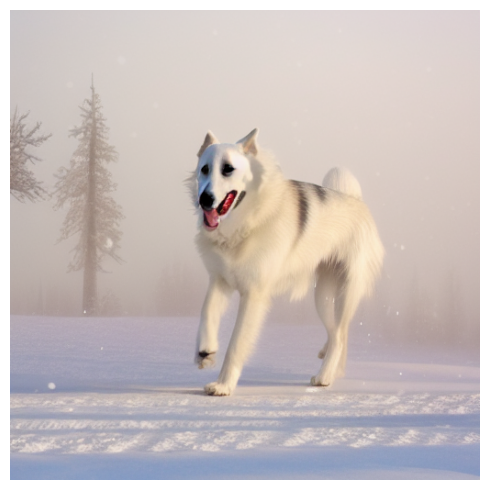

In [10]:
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)
plt.axis('off')
plt.tight_layout()
plt.show()

6. Change the cfg_scale parameter to 5 in the last code cell, and check to see what the output looks like.

In [11]:
import pipeline
import model_loader

models=model_loader.preload_models_from_standard_weights(model_file,
    device)
prompt="A dog walks on the white, snow-covered ground."    #The prompt used to modify the image
uncond_prompt=""
input_image = Image.open("files/horse.png")    #The existing image

output_image = pipeline.generate(    #Uses the generate() function in the pipeline module in the GitHub repository
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.5,    #aici----------------------------------
    do_cfg=True,
    cfg_scale=5, #aici------------------------------------------------
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)

100%|██████████| 25/25 [00:16<00:00,  1.56it/s]


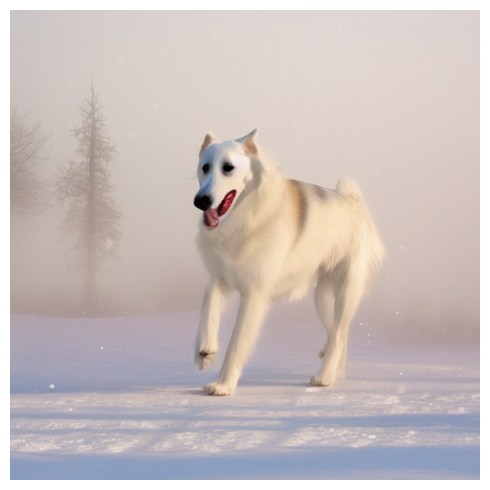

In [12]:
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)
plt.axis('off')
plt.tight_layout()
plt.show()